## imports

In [ ]:
import os
import json
import requests
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv
from typing import List, TypedDict, Optional, Dict, Any
from IPython.display import Markdown, display

from langchain_core.documents import Document
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langgraph.graph import StateGraph, END
from tavily import TavilyClient

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
import os
import time
from dotenv import load_dotenv

from datetime import datetime, timezone
from email.mime.text import MIMEText
import base64
from typing import Any, Dict, List

load_dotenv()


load_dotenv()

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
VECTOR_DB_PATH = "./sponsor_vector_db"
SPEAKER_VECTOR_DB_PATH = "./speaker_vector_db"
EXHIBITOR_VECTOR_DB_PATH = "./exhibitor_vector_db"
VENUE_VECTOR_DB_PATH = "./venue_vector_db"
COMMUNITY_VECTOR_DB_PATH = "./community_vector_db"
EVENT_OPS_VECTOR_DB_PATH = "./event_ops_vector_db"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
LLM_MODEL = "openai/gpt-oss-120b"

tavily_client = TavilyClient(api_key=TAVILY_API_KEY) if TAVILY_API_KEY else None


print("✅ Imports done")
print(f"🔑 OpenRouter key loaded: {'Yes' if OPENROUTER_API_KEY else 'NO — check .env'}")
print(f"🌐 Tavily key loaded: {'Yes' if TAVILY_API_KEY else 'NO — check .env'}")

✅ Imports done
🔑 OpenRouter key loaded: Yes
🌐 Tavily key loaded: Yes


## INGESTION

In [14]:
# ---------- 1) Sponsors ----------
sponsors_df = pd.read_csv("data/sponsors_v2.csv")
events_df = pd.read_csv("data/events_v2.csv")
sponsor_merged = sponsors_df.merge(events_df, on="event_name", how="left")

sponsor_docs = []
for _, row in tqdm(sponsor_merged.iterrows(), total=len(sponsor_merged), desc="Sponsor docs"):
    text = (
        f"{row['sponsor_name']} is a {row['industry']} company that sponsored "
        f"{row['event_name']}, a {row.get('category', 'AI')} conference held in "
        f"{row.get('city', 'Unknown')}, {row.get('country', 'Unknown')} in {row.get('year', 2025)}. "
        f"They were a {row['tier']} tier sponsor. "
        f"The event had approximately {row.get('attendance', 'N/A')} attendees."
    )
    sponsor_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "sponsor",
                "name": str(row.get("sponsor_name", "")),
                "industry": str(row.get("industry", "")),
                "tier": str(row.get("tier", "")),
                "event": str(row.get("event_name", "")),
                "country": str(row.get("country", "")),
                "category": str(row.get("category", "")),
            },
        )
    )




Sponsor docs: 100%|██████████| 200/200 [00:00<00:00, 6187.20it/s]


In [6]:

# ---------- 2) Speakers ----------
speakers_df = pd.read_csv("data/speakers_v2.csv")
speaker_merged = speakers_df.merge(events_df, on="event_name", how="left")

speaker_docs = []
for _, row in tqdm(speaker_merged.iterrows(), total=len(speaker_merged), desc="Speaker docs"):
    profile_type = "artist" if str(row.get("designation", "")).lower() in {"artist", "performer", "musician", "dj", "singer", "actor"} else "speaker"
    text = (
        f"{row.get('speaker_name', 'Unknown')} is a {row.get('designation', 'expert')} at {row.get('company', 'Unknown company')}. "
        f"They spoke/performed on {row.get('topic', 'general topic')} at {row.get('event_name', 'Unknown event')}. "
        f"Event category: {row.get('category', 'Unknown')}. "
        f"Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Estimated attendance: {row.get('attendance', 'N/A')}. Profile type: {profile_type}."
    )
    speaker_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "speaker_profile",
                "profile_name": str(row.get("speaker_name", "")),
                "profile_type": profile_type,
                "designation": str(row.get("designation", "")),
                "company": str(row.get("company", "")),
                "topic": str(row.get("topic", "")),
                "event": str(row.get("event_name", "")),
                "country": str(row.get("country", "")),
                "category": str(row.get("category", "")),
            },
        )
    )


Speaker docs: 100%|██████████| 200/200 [00:00<00:00, 4271.66it/s]


In [7]:

# ---------- 3) Exhibitors ----------
exhibitors_df = pd.read_csv("data/exhibitors.csv")
exhibitor_merged = exhibitors_df.merge(
    events_df[["event_name", "category", "country", "city", "year"]],
    on="event_name",
    how="left",
    suffixes=("_exhibitor", "_event"),
)

exhibitor_docs = []
for _, row in tqdm(exhibitor_merged.iterrows(), total=len(exhibitor_merged), desc="Exhibitor docs"):
    text = (
        f"{row.get('company_name', 'Unknown Company')} exhibited at {row.get('event_name', 'Unknown Event')}. "
        f"Exhibitor category: {row.get('category_exhibitor', 'Unknown')}. "
        f"Domain: {row.get('domain', 'Unknown')}. "
        f"Event category: {row.get('category_event', 'Unknown')}. "
        f"Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Year: {row.get('year', 'Unknown')}."
    )
    exhibitor_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "exhibitor",
                "company_name": str(row.get("company_name", "")),
                "exhibitor_category": str(row.get("category_exhibitor", "")),
                "domain": str(row.get("domain", "")),
                "event": str(row.get("event_name", "")),
                "event_category": str(row.get("category_event", "")),
                "country": str(row.get("country", "")),
                "city": str(row.get("city", "")),
                "year": str(row.get("year", "")),
            },
        )
    )


Exhibitor docs: 100%|██████████| 200/200 [00:00<00:00, 4714.32it/s]


In [8]:

# ---------- 4) Venues ----------
venues_df = pd.read_csv("data/venues.csv")

venue_docs = []
for _, row in tqdm(venues_df.iterrows(), total=len(venues_df), desc="Venue docs"):
    text = (
        f"{row.get('venue_name', 'Unknown Venue')} is located in {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Capacity is approximately {row.get('capacity', 'Unknown')} attendees. "
        f"Estimated cost is {row.get('estimated_cost', 'Unknown')}. "
        f"Venue type: {row.get('venue_type', 'Unknown')}. Setup type: {row.get('setup_type', 'Unknown')}. "
        f"Past events hosted: {row.get('past_events', 'N/A')}."
    )
    venue_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "venue",
                "venue_name": str(row.get("venue_name", "")),
                "city": str(row.get("city", "")),
                "country": str(row.get("country", "")),
                "capacity": str(row.get("capacity", "")),
                "estimated_cost": str(row.get("estimated_cost", "")),
                "past_events": str(row.get("past_events", "")),
                "venue_type": str(row.get("venue_type", "")),
                "setup_type": str(row.get("setup_type", "")),
            },
        )
    )


Venue docs: 100%|██████████| 20/20 [00:00<00:00, 3851.52it/s]


In [9]:

# ---------- 5) Communities ----------
communities_df = pd.read_csv("data/communities.csv")

community_docs = []
for _, row in tqdm(communities_df.iterrows(), total=len(communities_df), desc="Community docs"):
    text = (
        f"{row.get('community_name', 'Unknown Community')} is a {row.get('platform', 'community platform')} community "
        f"focused on {row.get('category', 'general')} with around {row.get('members_count', 'unknown')} members. "
        f"Engagement score is {row.get('engagement_score', 'unknown')}/10. "
        f"Location focus: {row.get('location_focus', 'Global')}. Link: {row.get('link', 'N/A')}."
    )
    community_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "community",
                "platform": str(row.get("platform", "")),
                "community_name": str(row.get("community_name", "")),
                "category": str(row.get("category", "")),
                "members_count": str(row.get("members_count", "")),
                "engagement_score": str(row.get("engagement_score", "")),
                "location_focus": str(row.get("location_focus", "")),
                "link": str(row.get("link", "")),
            },
        )
    )

Community docs: 100%|██████████| 20/20 [00:00<00:00, 3320.51it/s]


In [10]:

# ---------- 6) Event Ops (agenda, rooms, slots) ----------
sessions_df = pd.read_csv("data/sessions.csv")
rooms_df = pd.read_csv("data/rooms.csv")
time_slots_df = pd.read_csv("data/time_slots.csv")

event_ops_docs = []

# Room inventory docs
for _, row in tqdm(rooms_df.iterrows(), total=len(rooms_df), desc="EventOps room docs"):
    text = (
        f"Room resource: {row.get('room_name', 'Unknown Room')} with capacity {row.get('capacity', 'Unknown')} "
        f"and type {row.get('type', 'Unknown')}."
    )
    event_ops_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "event_ops_room",
                "room_name": str(row.get("room_name", "")),
                "capacity": str(row.get("capacity", "")),
                "room_type": str(row.get("type", "")),
            },
        )
    )

# Time slot docs
for _, row in tqdm(time_slots_df.iterrows(), total=len(time_slots_df), desc="EventOps slot docs"):
    text = f"Time slot resource from {row.get('start_time', 'NA')} to {row.get('end_time', 'NA')}."
    event_ops_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "event_ops_slot",
                "start_time": str(row.get("start_time", "")),
                "end_time": str(row.get("end_time", "")),
            },
        )
    )

# Session docs enriched with best-fit room candidates
for _, row in tqdm(sessions_df.iterrows(), total=len(sessions_df), desc="EventOps session docs"):
    expected = float(row.get('expected_audience', 0) or 0)
    room_candidates = rooms_df[rooms_df['capacity'] >= expected].copy()
    if room_candidates.empty:
        room_candidates = rooms_df.copy()
    room_candidates['capacity_gap'] = (room_candidates['capacity'] - expected).abs()
    top_rooms = room_candidates.sort_values('capacity_gap').head(3)['room_name'].tolist()

    text = (
        f"Session {row.get('session_id', 'NA')} on {row.get('topic', 'Unknown')} by {row.get('speaker_name', 'Unknown Speaker')}. "
        f"Track: {row.get('track', 'Unknown')}. Priority: {row.get('priority', 'normal')}. "
        f"Duration: {row.get('duration', 'Unknown')} minutes. Expected audience: {row.get('expected_audience', 'Unknown')}. "
        f"Best-fit room candidates: {', '.join(top_rooms)}."
    )
    event_ops_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "event_ops_session",
                "session_id": str(row.get("session_id", "")),
                "speaker_name": str(row.get("speaker_name", "")),
                "topic": str(row.get("topic", "")),
                "duration": str(row.get("duration", "")),
                "priority": str(row.get("priority", "")),
                "track": str(row.get("track", "")),
                "expected_audience": str(row.get("expected_audience", "")),
                "room_candidates": ",".join(top_rooms),
            },
        )
    )

EventOps session docs: 100%|██████████| 30/30 [00:00<00:00, 566.77it/s]


In [27]:
## EXIIBITOR 

EXHIBITORS_CSV_PATH = "data/exhibitors.csv"
EVENTS_CSV_PATH = "data/events_v2.csv"


# -- Ingest exhibitors into dedicated ChromaDB (run once) --
exhibitors_df = pd.read_csv(EXHIBITORS_CSV_PATH)
events_meta_df = pd.read_csv(EVENTS_CSV_PATH)[["event_name", "category", "country", "city", "year"]]

# category_exhibitor -> startup/tools/enterprise/individual from exhibitors.csv
# category_event    -> conference category from events_v2.csv
exhibitor_merged = exhibitors_df.merge(
    events_meta_df,
    on="event_name",
    how="left",
    suffixes=("_exhibitor", "_event")
)

exhibitor_docs: List[Document] = []
for _, row in tqdm(exhibitor_merged.iterrows(), total=len(exhibitor_merged), desc="Building exhibitor docs"):
    text = (
        f"{row.get('company_name', 'Unknown Company')} exhibited at {row.get('event_name', 'Unknown Event')}. "
        f"Exhibitor category: {row.get('category_exhibitor', 'Unknown')}. "
        f"Domain: {row.get('domain', 'Unknown')}. "
        f"Event category: {row.get('category_event', 'Unknown')}. "
        f"Location: {row.get('city', 'Unknown')}, {row.get('country', 'Unknown')}. "
        f"Year: {row.get('year', 'Unknown')}."
    )

    exhibitor_docs.append(
        Document(
            page_content=text,
            metadata={
                "type": "exhibitor",
                "company_name": str(row.get("company_name", "")),
                "exhibitor_category": str(row.get("category_exhibitor", "")),
                "domain": str(row.get("domain", "")),
                "event": str(row.get("event_name", "")),
                "event_category": str(row.get("category_event", "")),
                "country": str(row.get("country", "")),
                "city": str(row.get("city", "")),
                "year": str(row.get("year", "")),
            },
        )
    )


Building exhibitor docs: 100%|██████████| 200/200 [00:00<00:00, 5289.79it/s]


In [29]:

# ---------- Persist all DBs ----------
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

vectordb = Chroma.from_documents(
    documents=sponsor_docs,
    embedding=embedding_fn,
    persist_directory=VECTOR_DB_PATH,
)
vectordb.persist()

speaker_vectordb = Chroma.from_documents(
    documents=speaker_docs,
    embedding=embedding_fn,
    persist_directory=SPEAKER_VECTOR_DB_PATH,
)
speaker_vectordb.persist()

exhibitor_vectordb = Chroma.from_documents(
    documents=exhibitor_docs,
    embedding=embedding_fn,
    persist_directory=EXHIBITOR_VECTOR_DB_PATH,
)
exhibitor_vectordb.persist()

venue_vectordb = Chroma.from_documents(
    documents=venue_docs,
    embedding=embedding_fn,
    persist_directory=VENUE_VECTOR_DB_PATH,
)
venue_vectordb.persist()

community_vectordb = Chroma.from_documents(
    documents=community_docs,
    embedding=embedding_fn,
    persist_directory=COMMUNITY_VECTOR_DB_PATH,
)
community_vectordb.persist()

event_ops_vectordb = Chroma.from_documents(
    documents=event_ops_docs,
    embedding=embedding_fn,
    persist_directory=EVENT_OPS_VECTOR_DB_PATH,
)
event_ops_vectordb.persist()

exhibitor_vectordb = Chroma.from_documents(
    documents=exhibitor_docs,
    embedding=embedding_fn,
    persist_directory=EXHIBITOR_VECTOR_DB_PATH,
)
exhibitor_vectordb.persist()

print("✅ Unified ingestion complete")
print(f"   Sponsors   : {len(sponsor_docs)} -> {VECTOR_DB_PATH}")
print(f"   Speakers   : {len(speaker_docs)} -> {SPEAKER_VECTOR_DB_PATH}")
print(f"   Exhibitors : {len(exhibitor_docs)} -> {EXHIBITOR_VECTOR_DB_PATH}")
print(f"   Venues     : {len(venue_docs)} -> {VENUE_VECTOR_DB_PATH}")
print(f"   Communities: {len(community_docs)} -> {COMMUNITY_VECTOR_DB_PATH}")
print(f"   Event Ops  : {len(event_ops_docs)} -> {EVENT_OPS_VECTOR_DB_PATH}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3313.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Unified ingestion complete
   Sponsors   : 200 -> ./sponsor_vector_db
   Speakers   : 200 -> ./speaker_vector_db
   Exhibitors : 200 -> ./exhibitor_vector_db
   Venues     : 20 -> ./venue_vector_db
   Communities: 20 -> ./community_vector_db
   Event Ops  : 48 -> ./event_ops_vector_db


## loading existing DB

In [16]:
# Run this cell instead of Cell 3 on subsequent runs
embedding_fn = HuggingFaceEmbeddings(model_name=EMBED_MODEL)

vectordb = Chroma(
    persist_directory=VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

speaker_vectordb = Chroma(
    persist_directory=SPEAKER_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

exhibitor_vectordb = Chroma(
    persist_directory=EXHIBITOR_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

venue_vectordb = Chroma(
    persist_directory=VENUE_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

community_vectordb = Chroma(
    persist_directory=COMMUNITY_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

event_ops_vectordb = Chroma(
    persist_directory=EVENT_OPS_VECTOR_DB_PATH,
    embedding_function=embedding_fn
)

print(f"✅ Loaded Sponsor ChromaDB from {VECTOR_DB_PATH}")
print(f"   Sponsor documents in DB: {vectordb._collection.count()}")
print(f"✅ Loaded Speaker ChromaDB from {SPEAKER_VECTOR_DB_PATH}")
print(f"   Speaker documents in DB: {speaker_vectordb._collection.count()}")
print(f"✅ Loaded Exhibitor ChromaDB from {EXHIBITOR_VECTOR_DB_PATH}")
print(f"   Exhibitor documents in DB: {exhibitor_vectordb._collection.count()}")
print(f"✅ Loaded Venue ChromaDB from {VENUE_VECTOR_DB_PATH}")
print(f"   Venue documents in DB: {venue_vectordb._collection.count()}")
print(f"✅ Loaded Community ChromaDB from {COMMUNITY_VECTOR_DB_PATH}")
print(f"   Community documents in DB: {community_vectordb._collection.count()}")
print(f"✅ Loaded Event Ops ChromaDB from {EVENT_OPS_VECTOR_DB_PATH}")
print(f"   Event Ops documents in DB: {event_ops_vectordb._collection.count()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3757.19it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\KISHORE S\AppData\Local\Temp\ipykernel_35892\13717987.py:4: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(


✅ Loaded Sponsor ChromaDB from ./sponsor_vector_db
   Sponsor documents in DB: 3400
✅ Loaded Speaker ChromaDB from ./speaker_vector_db
   Speaker documents in DB: 2800
✅ Loaded Exhibitor ChromaDB from ./exhibitor_vector_db
   Exhibitor documents in DB: 5400
✅ Loaded Venue ChromaDB from ./venue_vector_db
   Venue documents in DB: 220
✅ Loaded Community ChromaDB from ./community_vector_db
   Community documents in DB: 200
✅ Loaded Event Ops ChromaDB from ./event_ops_vector_db
   Event Ops documents in DB: 480


## LLM HELPER OPENORUTER

In [17]:
LLM_MODEL          = "openai/gpt-oss-120b" 

In [19]:
llm = ChatOpenAI(
    model=LLM_MODEL,
    openai_api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
    temperature=0.1,
    max_tokens=4000,
)

def call_llm(prompt: str, temperature: float = 0.1, retries: int = 3) -> str:
    for attempt in range(retries):
        try:
            response = llm.invoke([HumanMessage(content=prompt)])
            return response.content.strip()   # ← AIMessage.content, not .json()

        except Exception as e:
            err = str(e)
            if "429" in err:
                wait = 60 * (attempt + 1)
                print(f"[429] Rate limited. Waiting {wait}s...")
                time.sleep(wait)
            elif "404" in err:
                print("[404] Model not found.")
                return "[LLM ERROR] Model not found"
            elif attempt == retries - 1:
                return f"[LLM ERROR] {e}"
            else:
                time.sleep(10)

    return "[LLM ERROR] Max retries exceeded"

# Test
test = call_llm("Reply with exactly: OK")
print("LLM test:", test)

LLM test: OK


## Graph state

In [20]:
class GraphState(TypedDict):
    # -- Inputs --
    user_input: dict  # sponsor/speaker/exhibitor/venue/pricing/community/event_ops/outreach request
    query: str

    # -- Router --
    selected_agent: str  # SPONSOR or SPEAKER or EXHIBITOR or VENUE or PRICING or COMMUNITY or EVENT_OPS or EMAIL_OUTREACH
    route_target: str
    required_agents: List[str]

    # -- Retrieval --
    retrieval_query: str
    raw_docs: List[str]
    relevant_docs: List[str]
    web_profiles: List[Dict[str, Any]]
    context: str

    # -- Outreach specific --
    contacts: List[Dict[str, Any]]
    emails: List[Dict[str, Any]]
    approved: bool
    email_logs: List[Dict[str, str]]

    # -- Generation --
    sponsors_answer: str
    pricing: Dict[str, Any]
    agent_outputs: Dict[str, Any]
    final_answer: str
    logs: List[str]

    # -- Self-RAG control --
    hallucination_verdict: str
    usefulness_verdict: str
    revise_count: int
    rewrite_count: int

print("✅ GraphState defined")

✅ GraphState defined


## Node Functions

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NODE 0 — agent_router
# LLM decides whether to run Sponsor, Speaker, Exhibitor, or Venue flow.
# ═══════════════════════════════════════════════════════════════════════════
# ---------------- MASTER ROUTER ----------------

def agent_router(state: GraphState) -> dict:
    ui = state["user_input"]
    prompt = (
        "You are an intent router for event-planning agents.\n\n"
        f"User request: {ui}\n\n"
        "Choose exactly one agent:\n"
        "- SPONSOR: sponsors, sponsorship proposal, sponsor prioritization\n"
        "- SPEAKER: speakers, artists, agenda mapping, thought leaders\n"
        "- EXHIBITOR: exhibitors, expo booths, companies to invite for exhibition\n"
        "- VENUE: venue shortlisting, city, capacity, footfall, budget\n"
        "- PRICING: ticket tiers, conversion, attendance forecast, revenue optimization\n"
        "- COMMUNITY: community discovery, GTM, promotion distribution plan\n"
        "- EVENT_OPS: agenda builder, conflict detection, room/speaker/time resource planning\n"
        "- EMAIL_OUTREACH: personalized outreach email drafting/sending for contacts\n\n"
        "Reply with ONLY one token: SPONSOR or SPEAKER or EXHIBITOR or VENUE or PRICING or COMMUNITY or EVENT_OPS or EMAIL_OUTREACH"
    )
    decision = call_llm(prompt, temperature=0.0).upper().strip()
    if "EMAIL_OUTREACH" in decision or "OUTREACH" in decision:
        selected_agent = "EMAIL_OUTREACH"
    elif "EVENT_OPS" in decision or "EVENT OPS" in decision or "OPS" in decision:
        selected_agent = "EVENT_OPS"
    elif "COMMUNITY" in decision:
        selected_agent = "COMMUNITY"
    elif "PRICING" in decision:
        selected_agent = "PRICING"
    elif "SPEAKER" in decision:
        selected_agent = "SPEAKER"
    elif "EXHIBITOR" in decision:
        selected_agent = "EXHIBITOR"
    elif "VENUE" in decision:
        selected_agent = "VENUE"
    else:
        selected_agent = "SPONSOR"

    route_target_map = {
        "SPONSOR": "sponsor",
        "SPEAKER": "speaker",
        "EXHIBITOR": "sponsor",  # Exhibitor remains handled in single-agent route of old graph paths.
        "VENUE": "venue",
        "PRICING": "pricing",
        "COMMUNITY": "gtm",
        "EVENT_OPS": "ops",
        "EMAIL_OUTREACH": "outreach",
    }

    print(f"[agent_router] selected -> {selected_agent}")
    return {"selected_agent": selected_agent, "route_target": route_target_map.get(selected_agent, "sponsor")}



# ═══════════════════════════════════════════════════════════════════════════
# SHARED SEARCH HELPER
# ═══════════════════════════════════════════════════════════════════════════
def tavily_search(query: str, max_results: int = 5) -> List[Dict[str, str]]:
    if tavily_client is None:
        return [{"title": "search_error", "url": "", "snippet": "Missing TAVILY_API_KEY"}]

    try:
        response = tavily_client.search(
            query=query,
            max_results=max_results,
            include_answer=False,
            include_raw_content=False,
            search_depth="advanced"
        )
        results = response.get("results", [])
        hits: List[Dict[str, str]] = []
        for r in results:
            hits.append({
                "title": r.get("title", ""),
                "url": r.get("url", ""),
                "snippet": r.get("content", "")
            })
        return hits
    except Exception as e:
        return [{"title": "search_error", "url": "", "snippet": str(e)}]



In [22]:



# ═══════════════════════════════════════════════════════════════════════════
# SPEAKER FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_speaker_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"{ui.get('event_topic', ui.get('category', 'AI'))} speaker artist candidates in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} with strong influence and keynote experience"
    )
    print(f"[build_speaker_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_speaker(state: GraphState) -> dict:
    results = speaker_vectordb.similarity_search(state["retrieval_query"], k=18)
    docs = [r.page_content for r in results]
    print(f"[retrieve_speaker] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_speaker_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating speaker/artist profile relevance for an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Profile info: {doc}\n\n"
            "Is this profile relevant to the event described? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]

    context = "\n\n".join(relevant)
    print(f"[filter_speaker_relevance] relevant={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def enrich_speaker_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    topic = ui.get("event_topic", ui.get("category", "AI"))

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        name = doc.split(" is a ")[0].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for name in candidates[:8]:
        q = f"{name} LinkedIn {topic} speaker profile followers publications keynote"
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": name,
            "kind": "speaker",
            "query": q,
            "hits": hits,
            "influence_signal_score": (
                joined.count("followers") + joined.count("published") + joined.count("author") +
                joined.count("keynote") + joined.count("speaker")
            )
        })

    print(f"[enrich_speaker_with_web] speaker web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_speaker(state: GraphState) -> dict:
    prompt = (
        "You are an event programming strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal speaker/artist context:\n"
        f"{state['context']}\n\n"
        "Tavily web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Recommend top speakers/artists and output strict markdown tables:\n"
        "1) Speaker/Artist Prioritization Table\n"
        "| Rank | Name | Type | Topic Fit | Past Experience Evidence | Influence Signals | Recommended Session | Priority Score (/100) |\n"
        "2) Agenda Mapping Table\n"
        "| Agenda Slot | Topic | Speaker/Artist | Session Format | Why This Match |"
    )
    answer = call_llm(prompt)
    print("[generate_speaker] speaker answer generated")
    return {"sponsors_answer": answer}


In [23]:


# ═══════════════════════════════════════════════════════════════════════════
# EXHIBITOR FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_exhibitor_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"companies that exhibited at {ui.get('category', 'technology')} conferences in {ui.get('location', 'global')} "
        "last 12 months startup enterprise tools individual exhibitor"
    )
    print(f"[build_exhibitor_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_exhibitor(state: GraphState) -> dict:
    results = exhibitor_vectordb.similarity_search(state["retrieval_query"], k=20)
    docs = [r.page_content for r in results]
    print(f"[retrieve_exhibitor] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_exhibitor_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating exhibitor relevance for an event expo hall.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Company info: {doc}\n\n"
            "Is this company a suitable potential exhibitor? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:8]

    context = "\n\n".join(relevant)
    print(f"[filter_exhibitor_relevance] relevant={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def enrich_exhibitor_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "technology")
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        marker = " exhibited at "
        name = doc.split(marker)[0].strip() if marker in doc else doc[:60].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for name in candidates[:10]:
        q = (
            f"{name} exhibited at conference expo {category} {location} "
            "startup enterprise tools individual"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": name,
            "kind": "exhibitor",
            "query": q,
            "hits": hits,
            "exhibit_signal": joined.count("exhibit") + joined.count("booth") + joined.count("expo"),
            "startup_signal": joined.count("startup"),
            "enterprise_signal": joined.count("enterprise"),
            "tools_signal": joined.count("platform") + joined.count("tool") + joined.count("saas"),
        })

    print(f"[enrich_exhibitor_with_web] exhibitor web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_exhibitor(state: GraphState) -> dict:
    prompt = (
        "You are an exhibition planning strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal company context:\n"
        f"{state['context']}\n\n"
        "Tavily web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Identify companies that exhibited at similar conferences/events.\n"
        "2) Suggest top potential exhibitors for this event.\n"
        "3) Cluster exhibitors by category: startup, enterprise, tools, individual.\n\n"
        "Output strict markdown with tables:\n"
        "A) Exhibitor Recommendation Table\n"
        "| Rank | Company | Why Relevant | Recent Exhibition Evidence | Priority Score (/100) |\n"
        "B) Exhibitor Cluster Table\n"
        "| Cluster Category | Companies | Rationale |"
    )
    answer = call_llm(prompt)
    print("[generate_exhibitor] exhibitor answer generated")
    return {"sponsors_answer": answer}



In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# SHARED SELF-RAG QUALITY NODES
# ═══════════════════════════════════════════════════════════════════════════
def check_hallucination(state: GraphState) -> dict:
    prompt = (
        "You are a fact-checker.\n\n"
        "Context (ground truth):\n"
        f"{state['context']}\n\n"
        "Web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Answer to verify:\n"
        f"{state['sponsors_answer']}\n\n"
        "Is the answer fully supported by the context, partially supported, or not supported?\n"
        "Reply ONLY with one of: Fully Supported / Partially Supported / No Support"
    )
    verdict = call_llm(prompt, temperature=0.0)
    print(f"[check_hallucination] verdict: {verdict}")
    return {"hallucination_verdict": verdict}


def revise(state: GraphState) -> dict:
    prompt = (
        "The following recommendation contains unsupported claims.\n\n"
        "Context (only use this):\n"
        f"{state['context']}\n\n"
        "Web evidence (only use this):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Original answer:\n"
        f"{state['sponsors_answer']}\n\n"
        "Rewrite using ONLY grounded information and preserve markdown table format."
    )
    revised = call_llm(prompt)
    new_count = state.get("revise_count", 0) + 1
    print(f"[revise] revision #{new_count}")
    return {"sponsors_answer": revised, "revise_count": new_count}


def check_usefulness(state: GraphState) -> dict:
    prompt = (
        "You are evaluating the quality of an event recommendation.\n\n"
        f"Event details: {state['user_input']}\n\n"
        f"Recommendation:\n{state['sponsors_answer']}\n\n"
        "Is this recommendation useful and actionable for the organizer? "
        "Reply ONLY with: Useful / Not Useful"
    )
    verdict = call_llm(prompt, temperature=0.0)
    print(f"[check_usefulness] verdict: {verdict}")
    return {"usefulness_verdict": verdict}


def rewrite_query(state: GraphState) -> dict:
    prompt = (
        "The following query did not retrieve useful information.\n\n"
        f"Original query: {state['retrieval_query']}\n"
        f"Event details: {state['user_input']}\n\n"
        "Write an improved, more specific search query. Return ONLY the query string."
    )
    new_query = call_llm(prompt, temperature=0.5)
    new_count = state.get("rewrite_count", 0) + 1
    print(f"[rewrite_query] new query: '{new_query}' (attempt #{new_count})")
    return {"retrieval_query": new_query, "rewrite_count": new_count}

In [25]:

# ═══════════════════════════════════════════════════════════════════════════
# VENUE FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_venue_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"venues in {ui.get('location', 'global')} for {ui.get('category', 'conference')} events "
        f"capacity around {ui.get('audience_size', ui.get('expected_footfall', '2000'))} "
        f"budget {ui.get('budget', 'medium')} setup type and past event usage"
    )
    print(f"[build_venue_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_venue(state: GraphState) -> dict:
    results = venue_vectordb.similarity_search(state["retrieval_query"], k=15)
    docs = [r.page_content for r in results]
    print(f"[retrieve_venue] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_venue_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating venue relevance for an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Venue info: {doc}\n\n"
            "Is this venue suitable based on city, expected footfall, and budget constraints? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]
        print("[filter_venue_relevance] fallback -> top 6 raw docs")
    else:
        print(f"[filter_venue_relevance] relevant={len(relevant)}")

    context = "\n\n".join(relevant)
    return {"relevant_docs": relevant, "context": context}


def enrich_venue_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        marker = " is located in "
        name = doc.split(marker)[0].strip() if marker in doc else doc[:60].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for venue in candidates[:8]:
        q = (
            f"{venue} {location} venue rental pricing capacity events hosted "
            "conference expo reviews"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": venue,
            "kind": "venue",
            "query": q,
            "hits": hits,
            "pricing_signal": joined.count("price") + joined.count("cost") + joined.count("rental"),
            "capacity_signal": joined.count("capacity") + joined.count("attendees") + joined.count("seating"),
            "event_history_signal": joined.count("hosted") + joined.count("conference") + joined.count("expo"),
        })

    print(f"[enrich_venue_with_web] venue web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate_venue(state: GraphState) -> dict:
    prompt = (
        "You are an event venue selection strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal venue context (primary grounding):\n"
        f"{state['context']}\n\n"
        "External web evidence from Tavily (secondary grounding):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Recommend top venues and output strict markdown tables:\n"
        "1) Venue Recommendation Table\n"
        "| Rank | Venue | City | Capacity | Estimated Cost | Budget Fit | Footfall Fit | Past Event Usage | Priority Score (/100) |\n"
        "2) Venue Shortlist Rationale Table\n"
        "| Venue | Best For | Setup Type | Key Strength | Potential Constraint |"
    )
    answer = call_llm(prompt)
    print("[generate_venue] venue answer generated")
    return {"sponsors_answer": answer}


In [26]:

# ═══════════════════════════════════════════════════════════════════════════
# SPONSOR FLOW
# ═══════════════════════════════════════════════════════════════════════════
def build_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"{ui.get('category', 'conference')} conference sponsors in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} "
        f"budget {ui.get('budget', 'medium')} "
        "recent sponsorships in last 12 months and marketing spend signals"
    )
    print(f"[build_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve(state: GraphState) -> dict:
    results = vectordb.similarity_search(state["retrieval_query"], k=18)
    docs = [r.page_content for r in results]
    print(f"[retrieve] sponsor docs={len(docs)}")
    return {"raw_docs": docs}


def filter_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating sponsor data relevance for an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Sponsor info: {doc}\n\n"
            "Is this sponsor relevant to the event described? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]
        print("[filter_relevance] fallback -> top 6 raw docs")
    else:
        print(f"[filter_relevance] relevant={len(relevant)}")

    context = "\n\n".join(relevant)
    return {"relevant_docs": relevant, "context": context}


def enrich_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    topic = ui.get("category", "conference")
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        sponsor_name = doc.split(" is a ")[0].strip()
        if sponsor_name and sponsor_name not in seen:
            seen.add(sponsor_name)
            candidates.append(sponsor_name)

    web_profiles = []
    for sponsor in candidates[:8]:
        q = (
            f"{sponsor} sponsorship {topic} {location} last 12 months "
            "marketing budget campaign announcement"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": sponsor,
            "kind": "sponsor",
            "query": q,
            "hits": hits,
            "marketing_spend_signal": joined.count("marketing") + joined.count("campaign") + joined.count("budget"),
            "recent_activity_signal": joined.count("2025") + joined.count("2026") + joined.count("recent"),
            "activity_signal": joined.count("sponsor") + joined.count("partnership") + joined.count("conference")
        })

    print(f"[enrich_with_web] sponsor web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


def generate(state: GraphState) -> dict:
    prompt = (
        "You are an expert sponsorship strategist.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal sponsor data (primary grounding):\n"
        f"{state['context']}\n\n"
        "External web evidence from Tavily (secondary grounding):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Recommend top sponsors and output strict markdown tables:\n"
        "1) Sponsor Prioritization Table\n"
        "| Rank | Sponsor | Industry | Geography Fit | Sponsorship Frequency | Marketing Spend Signal | Priority Score (/100) | Why Selected |\n"
        "2) Custom Sponsorship Proposal Table\n"
        "| Sponsor | Recommended Tier | Proposal Theme | Key Audience Benefit | Suggested Deliverables | Estimated Ask |"
    )
    answer = call_llm(prompt)
    print("[generate] sponsor answer generated")
    return {"sponsors_answer": answer}

In [30]:
## exhibitor flow nodes

def build_exhibitor_query(state: GraphState) -> dict:
    ui = state["user_input"]
    query = (
        f"companies that exhibited at {ui.get('category', 'technology')} conferences in {ui.get('location', 'global')} "
        "last 12 months startup enterprise tools individual exhibitor"
    )
    print(f"[build_exhibitor_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_exhibitor(state: GraphState) -> dict:
    results = exhibitor_vectordb.similarity_search(state["retrieval_query"], k=20)
    docs = [r.page_content for r in results]
    print(f"[retrieve_exhibitor] docs from exhibitor_vectordb={len(docs)}")
    return {"raw_docs": docs}


def filter_exhibitor_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating exhibitor relevance for an event expo hall.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Company info: {doc}\n\n"
            "Is this company a suitable potential exhibitor? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:8]

    context = "\n\n".join(relevant)
    print(f"[filter_exhibitor_relevance] relevant={len(relevant)}")
    return {"relevant_docs": relevant, "context": context}


def enrich_exhibitor_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "technology")
    location = ui.get("location", "global")

    candidates = []
    seen = set()
    for doc in state["relevant_docs"]:
        marker = " exhibited at "
        name = doc.split(marker)[0].strip() if marker in doc else doc[:60].strip()
        if name and name not in seen:
            seen.add(name)
            candidates.append(name)

    web_profiles = []
    for name in candidates[:10]:
        q = (
            f"{name} exhibited at conference expo {category} {location} "
            "startup enterprise tools individual"
        )
        hits = tavily_search(q, max_results=5)
        joined = " ".join(h.get("snippet", "") for h in hits).lower()

        web_profiles.append({
            "name": name,
            "kind": "exhibitor",
            "query": q,
            "hits": hits,
            "exhibit_signal": joined.count("exhibit") + joined.count("booth") + joined.count("expo"),
            "startup_signal": joined.count("startup"),
            "enterprise_signal": joined.count("enterprise"),
            "tools_signal": joined.count("platform") + joined.count("tool") + joined.count("saas"),
        })

    print(f"[enrich_exhibitor_with_web] exhibitor web profiles={len(web_profiles)}")
    return {"web_profiles": web_profiles}


In [ ]:
MAX_REVISIONS = 1   # max hallucination correction loops
MAX_REWRITES  = 1   # max query rewrite loops


def route_after_agent_router(state: GraphState) -> str:
    agent = state.get("selected_agent", "SPONSOR").upper()
    if "EVENT_OPS" in agent:
        return "event_ops_subgraph"
    if "COMMUNITY" in agent:
        return "community_subgraph"
    if "PRICING" in agent:
        return "pricing_subgraph"
    if "SPEAKER" in agent:
        return "speaker_subgraph"
    if "EXHIBITOR" in agent:
        return "exhibitor_subgraph"
    if "VENUE" in agent:
        return "venue_subgraph"
    return "sponsor_subgraph"

def route_after_hallucination_check(state: GraphState) -> str:
    """
    After hallucination check:
      - Fully Supported  -> proceed to usefulness check
      - Otherwise + retries left -> revise the answer
      - Otherwise + no retries   -> proceed anyway (best effort)
    """
    verdict = state.get("hallucination_verdict", "").upper()
    if "FULLY" in verdict:
        return "check_usefulness"
    if state.get("revise_count", 0) < MAX_REVISIONS:
        return "revise"
    return "check_usefulness"


def route_after_usefulness_check(state: GraphState) -> str:
    """
    After usefulness check:
      - Useful             -> done
      - Not Useful + retries left -> rewrite query and retrieve again
      - Not Useful + no retries   -> done (best effort)
    """
    verdict = state.get("usefulness_verdict", "").upper()
    if "NOT USEFUL" in verdict and state.get("rewrite_count", 0) < MAX_REWRITES:
        return "rewrite_query"
    return END

def route_after_rewrite(state: GraphState) -> str:
    agent = state.get("selected_agent", "SPONSOR").upper()
    if "EVENT_OPS" in agent:
        return "event_ops_subgraph"
    if "COMMUNITY" in agent:
        return "community_subgraph"
    if "PRICING" in agent:
        return "pricing_subgraph"
    if "SPEAKER" in agent:
        return "speaker_subgraph"
    if "EXHIBITOR" in agent:
        return "exhibitor_subgraph"
    if "VENUE" in agent:
        return "venue_subgraph"
    if "EMAIL_OUTREACH" in agent or "OUTREACH" in agent:
        return "email_subgraph"
    return "sponsor_subgraph"



print("✅ Routing functions defined")

✅ Routing functions defined


In [38]:
from pricing_engine import PricingEngine


# Lazy singleton so embeddings/model training are done once per kernel session.
pricing_engine = None


def get_pricing_engine() -> PricingEngine:
    global pricing_engine
    if pricing_engine is None:
        pricing_engine = PricingEngine(
            events_path="data/events_v2.csv",
            venues_path="data/venues.csv",
            pricing_tiers_path="data/pricing_tiers.csv",
            pricing_vector_db_path="./pricing_vector_db",
            embedding_model=EMBED_MODEL,
        )
        pricing_engine.load_data()
        pricing_engine.preprocess()   # builds and persists pricing embeddings
        pricing_engine.train_model()
        print("✅ PricingEngine initialized with embeddings + trained models")
    return pricing_engine


# If a rewritten query exists, preserve it in loops instead of rebuilding from scratch.
def _prefer_rewritten_query(state: GraphState) -> str:
    rq = str(state.get("retrieval_query", "")).strip()
    if state.get("rewrite_count", 0) > 0 and rq:
        return rq
    return ""


def build_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"{ui.get('category', 'conference')} conference sponsors in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} "
        f"budget {ui.get('budget', 'medium')} "
        "recent sponsorships in last 12 months and marketing spend signals"
    )
    print(f"[build_query] -> '{query}'")
    return {"retrieval_query": query}


def build_speaker_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_speaker_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"{ui.get('event_topic', ui.get('category', 'AI'))} speaker artist candidates in {ui.get('location', 'global')} "
        f"audience size {ui.get('audience_size', 'large')} with strong influence and keynote experience"
    )
    print(f"[build_speaker_query] -> '{query}'")
    return {"retrieval_query": query}


def build_exhibitor_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_exhibitor_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"companies that exhibited at {ui.get('category', 'technology')} conferences in {ui.get('location', 'global')} "
        "last 12 months startup enterprise tools individual exhibitor"
    )
    print(f"[build_exhibitor_query] -> '{query}'")
    return {"retrieval_query": query}


def build_venue_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_venue_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"venues in {ui.get('location', 'global')} for {ui.get('category', 'conference')} events "
        f"capacity around {ui.get('audience_size', ui.get('expected_footfall', '2000'))} "
        f"budget {ui.get('budget', 'medium')} setup type and past event usage"
    )
    print(f"[build_venue_query] -> '{query}'")
    return {"retrieval_query": query}


# ---------------- PRICING FLOW ----------------
def build_pricing_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_pricing_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"ticket pricing tiers and conversion for {ui.get('category', 'conference')} events "
        f"in {ui.get('city', ui.get('location', 'global'))} "
        f"audience {ui.get('audience_size', '2000')} budget {ui.get('budget', 'medium')}"
    )
    print(f"[build_pricing_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_pricing(state: GraphState) -> dict:
    engine = get_pricing_engine()
    results = engine.pricing_vectordb.similarity_search(state["retrieval_query"], k=12)
    docs = [r.page_content for r in results]
    print(f"[retrieve_pricing] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_pricing_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating historical pricing evidence relevance for an event.\n\n"
            f"Target event details: {state['user_input']}\n\n"
            f"Historical record: {doc}\n\n"
            "Is this historical record relevant for ticket pricing and footfall forecasting? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:6]
        print("[filter_pricing_relevance] fallback -> top 6 raw docs")
    else:
        print(f"[filter_pricing_relevance] relevant={len(relevant)}")

    return {"relevant_docs": relevant, "context": "\n\n".join(relevant)}


def enrich_pricing_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    city = ui.get("city", ui.get("location", "global"))
    category = ui.get("category", "conference")

    q = (
        f"{category} conference ticket pricing trends {city} conversion rate early bird regular vip "
        "attendance demand signals"
    )
    hits = tavily_search(q, max_results=6)
    joined = " ".join(h.get("snippet", "") for h in hits).lower()

    web_profiles = [{
        "kind": "pricing_market",
        "query": q,
        "hits": hits,
        "pricing_signal": joined.count("price") + joined.count("ticket") + joined.count("pricing"),
        "conversion_signal": joined.count("conversion") + joined.count("sellout") + joined.count("demand"),
        "footfall_signal": joined.count("attendance") + joined.count("footfall") + joined.count("visitors"),
    }]

    print("[enrich_pricing_with_web] pricing web profiles=1")
    return {"web_profiles": web_profiles}


def generate_pricing(state: GraphState) -> dict:
    engine = get_pricing_engine()
    result = engine.optimize_price(state["user_input"])

    prompt = (
        "You are a pricing and footfall strategist.\n\n"
        f"Target event details: {state['user_input']}\n\n"
        "Historical pricing context (from pricing ChromaDB):\n"
        f"{state['context']}\n\n"
        "External market evidence (Tavily):\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Model output (grounded base recommendation):\n"
        f"{json.dumps(result, ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "Produce strict markdown output with:\n"
        "1) Pricing Strategy Table\n"
        "| Tier | Price | Expected Conversion | Expected Tickets Sold | Expected Revenue |\n"
        "2) Forecast Summary Table\n"
        "| Base Price | Expected Attendance | Venue Capacity | Fill Rate | Total Revenue |\n"
        "3) Model Quality Table\n"
        "| Metric | Value |\n"
        "4) 3 short insights grounded ONLY in provided context and model output."
    )

    answer = call_llm(prompt)
    print("[generate_pricing] pricing answer generated")

    return {
        "pricing": result,
        "sponsors_answer": answer,
        "context": state["context"],
        "web_profiles": state.get("web_profiles", []),
    }

In [39]:

# ---------------- COMMUNITY & GTM FLOW ----------------
def build_community_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_community_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"{ui.get('category', 'technology')} communities for event promotion in {ui.get('location', 'global')} "
        f"city {ui.get('city', 'NA')} discord slack linkedin facebook engagement and member size"
    )
    print(f"[build_community_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_community(state: GraphState) -> dict:
    results = community_vectordb.similarity_search(state["retrieval_query"], k=15)
    docs = [r.page_content for r in results]
    print(f"[retrieve_community] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_community_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating community relevance for go-to-market promotion of an event.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Community profile: {doc}\n\n"
            "Is this community relevant for promotion and attendee acquisition? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:8]
        print("[filter_community_relevance] fallback -> top 8 raw docs")
    else:
        print(f"[filter_community_relevance] relevant={len(relevant)}")

    return {"relevant_docs": relevant, "context": "\n\n".join(relevant)}


def enrich_community_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "technology")
    location = ui.get("location", "global")

    market_query = (
        f"best online communities to promote {category} events in {location} "
        "discord slack linkedin facebook cvent eventlocations"
    )
    hits = tavily_search(market_query, max_results=6)
    joined = " ".join(h.get("snippet", "") for h in hits).lower()

    web_profiles = [{
        "kind": "community_gtm_market",
        "query": market_query,
        "hits": hits,
        "platform_signal": joined.count("discord") + joined.count("slack") + joined.count("linkedin") + joined.count("facebook"),
        "eventlisting_signal": joined.count("cvent") + joined.count("eventlocations"),
        "promotion_signal": joined.count("promote") + joined.count("engagement") + joined.count("audience"),
    }]

    print("[enrich_community_with_web] community web profiles=1")
    return {"web_profiles": web_profiles}


def generate_community_plan(state: GraphState) -> dict:
    prompt = (
        "You are a GTM strategist for event growth.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal community context (from ChromaDB):\n"
        f"{state['context']}\n\n"
        "External web evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Identify relevant communities, prioritize Discord first, then Slack/LinkedIn/Facebook.\n"
        "2) Categorize communities by niche.\n"
        "3) Suggest where to promote and message angles.\n"
        "4) Output a distribution plan.\n\n"
        "Output strict markdown tables:\n"
        "A) Community Prioritization Table\n"
        "| Rank | Community | Platform | Niche | Members | Engagement Score | Geo Fit | Why Selected |\n"
        "B) Messaging Strategy Table\n"
        "| Community | Primary Message | CTA | Content Format | Posting Cadence |\n"
        "C) Distribution Plan Table\n"
        "| Week | Platform | Community | Action | Goal Metric |"
    )

    answer = call_llm(prompt)
    print("[generate_community_plan] community GTM plan generated")
    return {"sponsors_answer": answer}

In [40]:

# ---------------- EVENT OPS / EXECUTION FLOW ----------------
def build_event_ops_query(state: GraphState) -> dict:
    rewritten = _prefer_rewritten_query(state)
    if rewritten:
        print(f"[build_event_ops_query] using rewritten query -> '{rewritten}'")
        return {"retrieval_query": rewritten}

    ui = state["user_input"]
    query = (
        f"event agenda scheduling for {ui.get('category', 'conference')} in {ui.get('location', 'global')} "
        f"audience {ui.get('audience_size', '2000')} with session conflicts rooms speakers and time slots"
    )
    print(f"[build_event_ops_query] -> '{query}'")
    return {"retrieval_query": query}


def retrieve_event_ops(state: GraphState) -> dict:
    results = event_ops_vectordb.similarity_search(state["retrieval_query"], k=24)
    docs = [r.page_content for r in results]
    print(f"[retrieve_event_ops] docs={len(docs)}")
    return {"raw_docs": docs}


def filter_event_ops_relevance(state: GraphState) -> dict:
    relevant = []
    for doc in state["raw_docs"]:
        prompt = (
            "You are evaluating agenda scheduling data relevance for event operations.\n\n"
            f"Event details: {state['user_input']}\n\n"
            f"Candidate data: {doc}\n\n"
            "Is this useful for agenda building, overlap/conflict detection, or resource planning? Reply ONLY with YES or NO."
        )
        verdict = call_llm(prompt, temperature=0.0)
        if "YES" in verdict.upper():
            relevant.append(doc)

    if not relevant:
        relevant = state["raw_docs"][:10]
        print("[filter_event_ops_relevance] fallback -> top 10 raw docs")
    else:
        print(f"[filter_event_ops_relevance] relevant={len(relevant)}")

    return {"relevant_docs": relevant, "context": "\n\n".join(relevant)}


def enrich_event_ops_with_web(state: GraphState) -> dict:
    ui = state["user_input"]
    category = ui.get("category", "conference")
    location = ui.get("location", "global")

    q = (
        f"conference agenda planning best practices {category} {location} session conflict detection "
        "room allocation speaker availability"
    )
    hits = tavily_search(q, max_results=6)
    joined = " ".join(h.get("snippet", "") for h in hits).lower()

    web_profiles = [{
        "kind": "event_ops_guidance",
        "query": q,
        "hits": hits,
        "schedule_signal": joined.count("agenda") + joined.count("schedule") + joined.count("timetable"),
        "conflict_signal": joined.count("conflict") + joined.count("overlap") + joined.count("collision"),
        "resource_signal": joined.count("room") + joined.count("speaker") + joined.count("capacity"),
    }]

    print("[enrich_event_ops_with_web] event ops web profiles=1")
    return {"web_profiles": web_profiles}


def generate_event_ops_plan(state: GraphState) -> dict:
    prompt = (
        "You are an event operations planner.\n\n"
        f"Event details: {state['user_input']}\n\n"
        "Internal ops context (sessions, rooms, slots from ChromaDB):\n"
        f"{state['context']}\n\n"
        "External evidence:\n"
        f"{json.dumps(state.get('web_profiles', []), ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Build a practical session agenda/timetable.\n"
        "2) Detect conflicts (time overlaps, speaker clashes, room over-capacity).\n"
        "3) Propose resource planning for rooms, speakers, and timing.\n\n"
        "Output format (mandatory):\n"
        "Final Event Plan:\n\n"
        "Schedule:\n"
        "HH:MM -> Session Name (Room)\n"
        "HH:MM -> Session Name (Room)\n\n"
        "Conflicts:\n"
        "- None OR list each conflict on a new bullet\n\n"
        "Resources:\n"
        "- X rooms allocated\n"
        "- Y volunteers required\n\n"
        "Notes:\n"
        "- High-demand sessions assigned to larger rooms\n"
        "- Buffer times included\n\n"
        "Rules:\n"
        "- Always include Schedule with at least 3 timeline entries when data allows.\n"
        "- Use 24-hour HH:MM times.\n"
        "- If no conflicts exist, write exactly: None\n"
        "- Keep output concise and practical for execution teams.\n"
    )

    answer = call_llm(prompt)
    print("[generate_event_ops_plan] event ops plan generated")
    return {"sponsors_answer": answer}

In [ ]:

# ---------------- ORCHESTRATION LAYER ----------------
AGENT_CANONICAL = ["sponsor", "speaker", "venue", "pricing", "gtm", "ops", "outreach"]


def _extract_query_text(state: GraphState) -> str:
    q = str(state.get("query", "")).strip()
    if q:
        return q

    ui = state.get("user_input", {})
    if isinstance(ui, dict):
        objective = str(ui.get("objective", "")).strip()
        category = str(ui.get("category", "event")).strip()
        location = str(ui.get("location", ui.get("city", "global"))).strip()
        composed = objective or f"Plan {category} event in {location}"
        return composed

    return str(ui)


def _parse_agent_list(raw: str) -> List[str]:
    text = (raw or "").strip()
    try:
        data = json.loads(text)
        if isinstance(data, dict):
            maybe_agents = data.get("agents", [])
        else:
            maybe_agents = data
        parsed = [str(x).strip().lower() for x in maybe_agents if str(x).strip()]
    except Exception:
        lowered = text.lower()
        parsed = [a for a in AGENT_CANONICAL if a in lowered]

    deduped = []
    for a in parsed:
        if a in AGENT_CANONICAL and a not in deduped:
            deduped.append(a)
    return deduped


def _planner_agents_with_llm(query_text: str) -> List[str]:
    planner_prompt = (
        "You are an orchestration planner for event operations.\n"
        "Given the user query, choose required agents from this exact list only: \n"
        "[sponsor, speaker, venue, pricing, gtm, ops, outreach].\n"
        "Use outreach when the query asks for email/contact outreach, follow-ups, or campaign execution.\n"
        "Return STRICT JSON only in this shape: {\"agents\": [\"...\"]}.\n"
        "Use one agent for simple requests and multiple for cross-functional requests.\n\n"
        f"User query: {query_text}\n"
    )
    raw = call_llm(planner_prompt, temperature=0.0)
    agents = _parse_agent_list(raw)
    return agents or ["sponsor"]


def _apply_dependency_order(agents: List[str]) -> List[str]:
    unique_agents = []
    for a in agents:
        if a in AGENT_CANONICAL and a not in unique_agents:
            unique_agents.append(a)

    rank = {"sponsor": 10, "speaker": 20, "venue": 30, "pricing": 40, "gtm": 50, "ops": 60}
    ordered = sorted(unique_agents, key=lambda x: rank.get(x, 999))
    return ordered


def _single_agent_to_selected(agent: str) -> str:
    mapping = {
        "sponsor": "SPONSOR",
        "speaker": "SPEAKER",
        "venue": "VENUE",
        "pricing": "PRICING",
        "gtm": "COMMUNITY",
        "ops": "EVENT_OPS",
        "outreach": "EMAIL_OUTREACH",
    }
    return mapping.get(agent, "SPONSOR")



def router_node(state: GraphState) -> dict:
    query_text = _extract_query_text(state)
    logs = list(state.get("logs", []))

    planned = _planner_agents_with_llm(query_text)
    if len(planned) == 1:
        route_target = planned[0]
        selected = _single_agent_to_selected(planned[0])
        logs.append(f"Router picked single agent: {planned[0]}")
    else:
        route_target = "coordinator"
        selected = "COORDINATOR"
        logs.append(f"Router escalated to coordinator for agents: {planned}")

    print(f"[router_node] route_target={route_target}, planned={planned}")
    return {
        "query": query_text,
        "required_agents": planned,
        "route_target": route_target,
        "selected_agent": selected,
        "logs": logs,
    }


def route_after_router_node(state: GraphState) -> str:
    target = str(state.get("route_target", "sponsor")).lower()
    mapping = {
        "sponsor": "sponsor_subgraph",
        "speaker": "speaker_subgraph",
        "venue": "venue_subgraph",
        "pricing": "pricing_subgraph",
        "gtm": "community_subgraph",
        "ops": "event_ops_subgraph",
        "outreach": "email_subgraph",
        "coordinator": "coordinator_node",
    }
    return mapping.get(target, "sponsor_subgraph")



def _run_agent_subgraph(agent: str, state: GraphState) -> Dict[str, Any]:
    subgraph_map = {
        "sponsor": sponsor_subgraph,
        "speaker": speaker_subgraph,
        "venue": venue_subgraph,
        "pricing": pricing_subgraph,
        "gtm": community_subgraph,
        "ops": event_ops_subgraph,
        "outreach": email_subgraph,
    }
    selected_map = {
        "sponsor": "SPONSOR",
        "speaker": "SPEAKER",
        "venue": "VENUE",
        "pricing": "PRICING",
        "gtm": "COMMUNITY",
        "ops": "EVENT_OPS",
        "outreach": "EMAIL_OUTREACH",
    }

    sg = subgraph_map.get(agent)
    if sg is None:
        return {"answer": f"Unsupported agent: {agent}"}

    invoke_state = dict(state)
    invoke_state["selected_agent"] = selected_map.get(agent, "SPONSOR")
    result = sg.invoke(invoke_state)

    return {
        "answer": result.get("sponsors_answer", ""),
        "selected_agent": invoke_state["selected_agent"],
        "context": result.get("context", ""),
        "pricing": result.get("pricing", {}),
        "emails": result.get("emails", []),
        "email_logs": result.get("email_logs", []),
    }


def coordinator_node(state: GraphState) -> dict:
    query_text = _extract_query_text(state)
    logs = list(state.get("logs", []))
    outputs = dict(state.get("agent_outputs", {}))
    shared_state = dict(state)

    planned_agents = state.get("required_agents") or _planner_agents_with_llm(query_text)
    ordered_agents = _apply_dependency_order(planned_agents)

    # Enforce dependency order: venue -> pricing, speaker -> ops, pricing -> gtm
    deps = [("venue", "pricing"), ("speaker", "ops"), ("pricing", "gtm")]
    for left, right in deps:
        if left in ordered_agents and right in ordered_agents and ordered_agents.index(left) > ordered_agents.index(right):
            ordered_agents.remove(left)
            idx = ordered_agents.index(right)
            ordered_agents.insert(idx, left)

    call_reason = {
        "venue": "capacity and feasibility",
        "pricing": "budget fit and revenue optimization",
        "gtm": "distribution and demand generation",
        "speaker": "program quality and audience fit",
        "ops": "schedule and execution readiness",
        "sponsor": "commercial partnership alignment",
    }

    for agent in ordered_agents:
        if agent in outputs and outputs[agent].get("answer"):
            logs.append(f"Reused cached {agent} output")
            shared_state["sponsors_answer"] = outputs[agent].get("answer", shared_state.get("sponsors_answer", ""))
            if outputs[agent].get("context"):
                shared_state["context"] = outputs[agent]["context"]
            if outputs[agent].get("pricing"):
                shared_state["pricing"] = outputs[agent]["pricing"]
            continue

        logs.append(f"Called {agent} agent for {call_reason.get(agent, 'planning')}")
        outputs[agent] = _run_agent_subgraph(agent, shared_state)
        shared_state["sponsors_answer"] = outputs[agent].get("answer", shared_state.get("sponsors_answer", ""))
        if outputs[agent].get("context"):
            shared_state["context"] = outputs[agent]["context"]
        if outputs[agent].get("pricing"):
            shared_state["pricing"] = outputs[agent]["pricing"]

    print(f"[coordinator_node] ordered_agents={ordered_agents}")
    return {
        "query": query_text,
        "required_agents": ordered_agents,
        "agent_outputs": outputs,
        "logs": logs,
    }


def combine_results(state: GraphState) -> dict:
    query_text = _extract_query_text(state)
    logs = list(state.get("logs", []))
    outputs = state.get("agent_outputs", {})

    prompt = (
        "You are a coordinator that integrates multi-agent event plans into one best solution.\n"
        "User query and objective:\n"
        f"{query_text}\n\n"
        "Agent outputs (JSON):\n"
        f"{json.dumps(outputs, ensure_ascii=True, indent=2)}\n\n"
        "Task:\n"
        "1) Merge results into one integrated plan.\n"
        "2) Explicitly resolve conflicts/contradictions between agents.\n"
        "3) Show relationships and dependencies across venue, pricing, speaker, ops, and GTM decisions.\n"
        "4) Output a concise actionable final recommendation.\n"
    )
    final_text = call_llm(prompt)
    logs.append("Combined multi-agent outputs into integrated final answer")
    print("[combine_results] final integrated answer generated")
    return {"sponsors_answer": final_text, "final_answer": final_text, "logs": logs}


In [ ]:
# mailing agent


CONTACTS_CSV_PATH = "data/contacts.csv"
CONTACT_VECTOR_DB_PATH = "./contact_vector_db"
GMAIL_SCOPES = ["https://www.googleapis.com/auth/gmail.send"]

contact_vectordb = None


def _safe_text(value: Any, default: str = "") -> str:
    if value is None:
        return default
    return str(value).strip()


def get_contact_vectordb() -> Chroma:
    global contact_vectordb
    if contact_vectordb is not None:
        return contact_vectordb

    if 'embedding_fn' not in globals() or embedding_fn is None:
        raise RuntimeError("embedding_fn is not initialized. Run ingestion/load cells first.")

    try:
        existing = Chroma(
            persist_directory=CONTACT_VECTOR_DB_PATH,
            embedding_function=embedding_fn,
        )
        if existing._collection.count() > 0:
            contact_vectordb = existing
            print(f"✅ Loaded Contact ChromaDB from {CONTACT_VECTOR_DB_PATH} with {existing._collection.count()} docs")
            return contact_vectordb
    except Exception:
        pass

    contacts_df = pd.read_csv(CONTACTS_CSV_PATH)
    contact_docs: List[Document] = []

    for _, row in tqdm(contacts_df.iterrows(), total=len(contacts_df), desc="Contact docs"):
        text = (
            f"{_safe_text(row.get('name'), 'Unknown Contact')} works at {_safe_text(row.get('company'), 'Unknown Company')} "
            f"as {_safe_text(row.get('role'), 'Unknown Role')}. "
            f"Contact type: {_safe_text(row.get('type'), 'unknown')}. "
            f"Industry: {_safe_text(row.get('industry'), 'unknown')}. "
            f"Email: {_safe_text(row.get('email'), 'missing')}. "
            f"LinkedIn: {_safe_text(row.get('linkedin'), 'missing')}. "
            f"Relevance score: {_safe_text(row.get('relevance_score'), '0')}."
        )

        contact_docs.append(
            Document(
                page_content=text,
                metadata={
                    "type": "contact",
                    "name": _safe_text(row.get("name")),
                    "company": _safe_text(row.get("company")),
                    "role": _safe_text(row.get("role")),
                    "contact_type": _safe_text(row.get("type")),
                    "industry": _safe_text(row.get("industry")),
                    "email": _safe_text(row.get("email")),
                    "linkedin": _safe_text(row.get("linkedin")),
                    "relevance_score": _safe_text(row.get("relevance_score")),
                },
            )
        )

    contact_vectordb = Chroma.from_documents(
        documents=contact_docs,
        embedding=embedding_fn,
        persist_directory=CONTACT_VECTOR_DB_PATH,
    )
    contact_vectordb.persist()
    print(f"✅ Built Contact ChromaDB -> {CONTACT_VECTOR_DB_PATH} ({len(contact_docs)} docs)")
    return contact_vectordb


def retrieve_contacts(state: GraphState) -> dict:
    ui = state.get("user_input", {})
    objective = _safe_text(ui.get("objective"), "")
    category = _safe_text(ui.get("category"), "conference")
    location = _safe_text(ui.get("location", ui.get("city", "global")), "global")

    query = state.get("retrieval_query") or (
        f"contacts for {category} event outreach in {location} with high relevance score {objective} "
        "sponsor speaker community"
    )

    db = get_contact_vectordb()
    results = db.similarity_search(query, k=12)

    contacts = []
    for r in results:
        md = dict(r.metadata or {})
        contact = {
            "name": _safe_text(md.get("name"), "Unknown"),
            "company": _safe_text(md.get("company"), "Unknown"),
            "role": _safe_text(md.get("role"), "Unknown"),
            "type": _safe_text(md.get("contact_type"), "unknown"),
            "industry": _safe_text(md.get("industry"), "unknown"),
            "email": _safe_text(md.get("email"), ""),
            "linkedin": _safe_text(md.get("linkedin"), ""),
            "relevance_score": _safe_text(md.get("relevance_score"), "0"),
            "doc": r.page_content,
        }
        if contact["email"]:
            contacts.append(contact)

    # Deduplicate by email while preserving rank.
    deduped = []
    seen = set()
    for c in contacts:
        email = c["email"].lower()
        if email not in seen:
            seen.add(email)
            deduped.append(c)

    context_lines = []
    for c in deduped[:8]:
        context_lines.append(
            f"{c['name']} | {c['company']} | {c['role']} | type={c['type']} | industry={c['industry']} | relevance={c['relevance_score']}"
        )

    print(f"[retrieve_contacts] query='{query}' contacts={len(deduped)}")
    return {
        "retrieval_query": query,
        "relevant_docs": [c["doc"] for c in deduped],
        "context": "\n".join(context_lines),
        "contacts": deduped,
        "approved": bool(state.get("approved", False)),
        "email_logs": list(state.get("email_logs", [])),
    }


def generate_emails(state: GraphState) -> dict:
    ui = state.get("user_input", {})
    event_details = {
        "event_name": _safe_text(ui.get("event_name"), "Upcoming Event"),
        "category": _safe_text(ui.get("category"), "conference"),
        "topic": _safe_text(ui.get("event_topic", ui.get("category", "conference"))),
        "location": _safe_text(ui.get("location", ui.get("city", "global"))),
        "audience_size": _safe_text(ui.get("audience_size"), "N/A"),
        "budget": _safe_text(ui.get("budget"), "N/A"),
        "objective": _safe_text(ui.get("objective"), "partnership and event collaboration"),
    }

    generated = []
    for contact in state.get("contacts", [])[:10]:
        why_relevant = (
            f"{contact['name']} is a {contact['type']} contact from {contact['company']} in {contact['industry']}, "
            f"role={contact['role']}, relevance_score={contact['relevance_score']}."
        )

        prompt = (
            "You are a professional B2B outreach specialist.\n\n"
            "Generate one personalized outreach email in STRICT JSON with keys: subject, body.\n"
            "Rules:\n"
            "- Body must be 120 words or fewer\n"
            "- Professional, concise, and personalized\n"
            "- Include a clear CTA\n"
            "- Do not hallucinate facts\n"
            "- No markdown\n\n"
            f"Event details: {json.dumps(event_details, ensure_ascii=True)}\n"
            f"Contact: {json.dumps(contact, ensure_ascii=True)}\n"
            f"Why relevant: {why_relevant}\n"
        )

        raw = call_llm(prompt, temperature=0.2)
        subject = "Quick collaboration opportunity"
        body = "Hi there, I would love to connect about a relevant opportunity for our upcoming event. Are you open to a short call this week?"

        try:
            parsed = json.loads(raw)
            subject = _safe_text(parsed.get("subject"), subject)
            body = _safe_text(parsed.get("body"), body)
        except Exception:
            fallback_prompt = (
                "Rewrite the following into JSON only with keys subject and body. Keep body <= 120 words.\n"
                f"Text: {raw}"
            )
            retry = call_llm(fallback_prompt, temperature=0.0)
            try:
                parsed = json.loads(retry)
                subject = _safe_text(parsed.get("subject"), subject)
                body = _safe_text(parsed.get("body"), body)
            except Exception:
                pass

        words = body.split()
        if len(words) > 120:
            body = " ".join(words[:120])

        generated.append({
            "to": contact["email"],
            "name": contact["name"],
            "company": contact["company"],
            "contact_type": contact["type"],
            "subject": subject,
            "body": body,
            "why_relevant": why_relevant,
            "status": "pending",
        })

    summary = (
        "Generated outreach drafts. Review and approve before sending.\n\n" +
        "\n".join([f"- {e['to']} :: {e['subject']}" for e in generated])
    )

    print(f"[generate_emails] generated={len(generated)}")
    return {
        "emails": generated,
        "sponsors_answer": summary,
        "approved": bool(state.get("approved", False)),
    }


def quality_check(state: GraphState) -> dict:
    checked = []
    for email_obj in state.get("emails", []):
        prompt = (
            "You are a strict email quality reviewer.\n"
            "Validate personalization, clarity, and CTA.\n"
            "If improvements are needed, revise email body while keeping it professional and <=120 words.\n"
            "Return STRICT JSON with keys: pass (true/false), feedback, subject, body.\n\n"
            f"Draft: {json.dumps(email_obj, ensure_ascii=True)}"
        )
        raw = call_llm(prompt, temperature=0.0)

        updated = dict(email_obj)
        try:
            parsed = json.loads(raw)
            updated["quality_feedback"] = _safe_text(parsed.get("feedback"), "")
            updated["subject"] = _safe_text(parsed.get("subject"), updated["subject"])
            updated["body"] = _safe_text(parsed.get("body"), updated["body"])
            words = updated["body"].split()
            if len(words) > 120:
                updated["body"] = " ".join(words[:120])
        except Exception:
            updated["quality_feedback"] = "Quality parser fallback used"

        checked.append(updated)

    # Default safety gate: never auto-send unless user explicitly sets approved=True.
    approved = bool(state.get("approved", False))
    print(f"[quality_check] emails={len(checked)} approved={approved}")
    return {"emails": checked, "approved": approved}


def user_approval_gate(state: GraphState) -> dict:
    approved = bool(state.get("approved", False))
    print(f"[user_approval_gate] approved={approved}")
    return {"approved": approved}


def _get_gmail_service() -> Any:
    try:
        from google.auth.transport.requests import Request
        from google.oauth2.credentials import Credentials
        from google_auth_oauthlib.flow import InstalledAppFlow
        from googleapiclient.discovery import build
    except Exception as e:
        raise RuntimeError(
            "Missing Gmail dependencies. Install: google-api-python-client google-auth-httplib2 google-auth-oauthlib"
        ) from e

    creds = None
    token_path = os.getenv("GMAIL_TOKEN_PATH", "token.json")

    if os.path.exists(token_path):
        creds = Credentials.from_authorized_user_file(token_path, GMAIL_SCOPES)

    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            cred_path = os.getenv("GMAIL_CREDENTIALS_PATH", "credentials.json")
            if not os.path.exists(cred_path) and os.path.exists("credentials.json.json"):
                cred_path = "credentials.json.json"
            if not os.path.exists(cred_path):
                raise FileNotFoundError(
                    f"Gmail OAuth credentials file not found. Checked: {cred_path}"
                )
            flow = InstalledAppFlow.from_client_secrets_file(cred_path, GMAIL_SCOPES)
            creds = flow.run_local_server(port=0)

        with open(token_path, "w", encoding="utf-8") as token:
            token.write(creds.to_json())

    return build("gmail", "v1", credentials=creds)


def _send_gmail_message(service: Any, sender: str, to_email: str, subject: str, body: str) -> Dict[str, Any]:
    msg = MIMEText(body)
    msg["to"] = to_email
    msg["from"] = sender
    msg["subject"] = subject

    raw = base64.urlsafe_b64encode(msg.as_bytes()).decode()
    return service.users().messages().send(userId="me", body={"raw": raw}).execute()


def send_emails(state: GraphState) -> dict:
    approved = bool(state.get("approved", False))
    logs = list(state.get("email_logs", []))
    emails = list(state.get("emails", []))

    if not approved:
        now = datetime.now(timezone.utc).isoformat()
        for e in emails:
            logs.append({
                "email": e.get("to", ""),
                "status": "pending",
                "timestamp": now,
            })
        print("[send_emails] skipped because approved=False")
        return {"emails": emails, "email_logs": logs, "sponsors_answer": "Approval pending. Emails were not sent."}

    sender = os.getenv("OUTREACH_SENDER_EMAIL", "me")
    service = None
    try:
        service = _get_gmail_service()
    except Exception as e:
        now = datetime.now(timezone.utc).isoformat()
        for eobj in emails:
            eobj["status"] = "failed"
            logs.append({
                "email": eobj.get("to", ""),
                "status": "failed",
                "timestamp": now,
            })
        err = f"[send_emails] auth/setup failed: {e}"
        print(err)
        return {"emails": emails, "email_logs": logs, "sponsors_answer": err}

    for email_obj in emails:
        to_email = email_obj.get("to", "")
        status = "sent"
        try:
            _send_gmail_message(
                service=service,
                sender=sender,
                to_email=to_email,
                subject=email_obj.get("subject", ""),
                body=email_obj.get("body", ""),
            )
            email_obj["status"] = "sent"
        except Exception as exc:
            msg = str(exc).lower()
            status = "failed"
            if "rate" in msg or "429" in msg:
                status = "failed"
            email_obj["status"] = status
            email_obj["error"] = str(exc)

        logs.append({
            "email": to_email,
            "status": status,
            "timestamp": datetime.now(timezone.utc).isoformat(),
        })

    sent_count = sum(1 for e in emails if e.get("status") == "sent")
    print(f"[send_emails] sent={sent_count}/{len(emails)}")
    return {
        "emails": emails,
        "email_logs": logs,
        "sponsors_answer": f"Email sending completed. Sent {sent_count}/{len(emails)} emails.",
    }


## Graph Building

In [ ]:

# ---------------- SUBGRAPH BUILDERS ----------------
def build_sponsor_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_query", build_query)
    sg.add_node("retrieve", retrieve)
    sg.add_node("filter_relevance", filter_relevance)
    sg.add_node("enrich_with_web", enrich_with_web)
    sg.add_node("generate", generate)
    sg.set_entry_point("build_query")
    sg.add_edge("build_query", "retrieve")
    sg.add_edge("retrieve", "filter_relevance")
    sg.add_edge("filter_relevance", "enrich_with_web")
    sg.add_edge("enrich_with_web", "generate")
    sg.add_edge("generate", END)
    return sg.compile()


def build_speaker_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_speaker_query", build_speaker_query)
    sg.add_node("retrieve_speaker", retrieve_speaker)
    sg.add_node("filter_speaker_relevance", filter_speaker_relevance)
    sg.add_node("enrich_speaker_with_web", enrich_speaker_with_web)
    sg.add_node("generate_speaker", generate_speaker)
    sg.set_entry_point("build_speaker_query")
    sg.add_edge("build_speaker_query", "retrieve_speaker")
    sg.add_edge("retrieve_speaker", "filter_speaker_relevance")
    sg.add_edge("filter_speaker_relevance", "enrich_speaker_with_web")
    sg.add_edge("enrich_speaker_with_web", "generate_speaker")
    sg.add_edge("generate_speaker", END)
    return sg.compile()


def build_exhibitor_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_exhibitor_query", build_exhibitor_query)
    sg.add_node("retrieve_exhibitor", retrieve_exhibitor)
    sg.add_node("filter_exhibitor_relevance", filter_exhibitor_relevance)
    sg.add_node("enrich_exhibitor_with_web", enrich_exhibitor_with_web)
    sg.add_node("generate_exhibitor", generate_exhibitor)
    sg.set_entry_point("build_exhibitor_query")
    sg.add_edge("build_exhibitor_query", "retrieve_exhibitor")
    sg.add_edge("retrieve_exhibitor", "filter_exhibitor_relevance")
    sg.add_edge("filter_exhibitor_relevance", "enrich_exhibitor_with_web")
    sg.add_edge("enrich_exhibitor_with_web", "generate_exhibitor")
    sg.add_edge("generate_exhibitor", END)
    return sg.compile()


def build_venue_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_venue_query", build_venue_query)
    sg.add_node("retrieve_venue", retrieve_venue)
    sg.add_node("filter_venue_relevance", filter_venue_relevance)
    sg.add_node("enrich_venue_with_web", enrich_venue_with_web)
    sg.add_node("generate_venue", generate_venue)
    sg.set_entry_point("build_venue_query")
    sg.add_edge("build_venue_query", "retrieve_venue")
    sg.add_edge("retrieve_venue", "filter_venue_relevance")
    sg.add_edge("filter_venue_relevance", "enrich_venue_with_web")
    sg.add_edge("enrich_venue_with_web", "generate_venue")
    sg.add_edge("generate_venue", END)
    return sg.compile()


def build_pricing_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_pricing_query", build_pricing_query)
    sg.add_node("retrieve_pricing", retrieve_pricing)
    sg.add_node("filter_pricing_relevance", filter_pricing_relevance)
    sg.add_node("enrich_pricing_with_web", enrich_pricing_with_web)
    sg.add_node("generate_pricing", generate_pricing)
    sg.set_entry_point("build_pricing_query")
    sg.add_edge("build_pricing_query", "retrieve_pricing")
    sg.add_edge("retrieve_pricing", "filter_pricing_relevance")
    sg.add_edge("filter_pricing_relevance", "enrich_pricing_with_web")
    sg.add_edge("enrich_pricing_with_web", "generate_pricing")
    sg.add_edge("generate_pricing", END)
    return sg.compile()


def build_community_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_community_query", build_community_query)
    sg.add_node("retrieve_community", retrieve_community)
    sg.add_node("filter_community_relevance", filter_community_relevance)
    sg.add_node("enrich_community_with_web", enrich_community_with_web)
    sg.add_node("generate_community_plan", generate_community_plan)
    sg.set_entry_point("build_community_query")
    sg.add_edge("build_community_query", "retrieve_community")
    sg.add_edge("retrieve_community", "filter_community_relevance")
    sg.add_edge("filter_community_relevance", "enrich_community_with_web")
    sg.add_edge("enrich_community_with_web", "generate_community_plan")
    sg.add_edge("generate_community_plan", END)
    return sg.compile()


def build_event_ops_subgraph():
    sg = StateGraph(GraphState)
    sg.add_node("build_event_ops_query", build_event_ops_query)
    sg.add_node("retrieve_event_ops", retrieve_event_ops)
    sg.add_node("filter_event_ops_relevance", filter_event_ops_relevance)
    sg.add_node("enrich_event_ops_with_web", enrich_event_ops_with_web)
    sg.add_node("generate_event_ops_plan", generate_event_ops_plan)
    sg.set_entry_point("build_event_ops_query")
    sg.add_edge("build_event_ops_query", "retrieve_event_ops")
    sg.add_edge("retrieve_event_ops", "filter_event_ops_relevance")
    sg.add_edge("filter_event_ops_relevance", "enrich_event_ops_with_web")
    sg.add_edge("enrich_event_ops_with_web", "generate_event_ops_plan")
    sg.add_edge("generate_event_ops_plan", END)
    return sg.compile()

def build_email_subgraph():
    email_graph = StateGraph(GraphState)
    email_graph.add_node("retrieve_contacts", retrieve_contacts)
    email_graph.add_node("generate_emails", generate_emails)
    email_graph.add_node("quality_check", quality_check)
    email_graph.add_node("user_approval_gate", user_approval_gate)
    email_graph.add_node("send_emails", send_emails)

    email_graph.set_entry_point("retrieve_contacts")
    email_graph.add_edge("retrieve_contacts", "generate_emails")
    email_graph.add_edge("generate_emails", "quality_check")
    email_graph.add_edge("quality_check", "user_approval_gate")
    email_graph.add_edge("user_approval_gate", "send_emails")
    email_graph.add_edge("send_emails", END)
    return email_graph.compile()


email_subgraph = build_email_subgraph()
sponsor_subgraph = build_sponsor_subgraph()
speaker_subgraph = build_speaker_subgraph()
exhibitor_subgraph = build_exhibitor_subgraph()
venue_subgraph = build_venue_subgraph()
pricing_subgraph = build_pricing_subgraph()
community_subgraph = build_community_subgraph()
event_ops_subgraph = build_event_ops_subgraph()

In [ ]:

builder = StateGraph(GraphState)

builder.add_node("router_node", router_node)
builder.add_node("coordinator_node", coordinator_node)
builder.add_node("combine_results", combine_results)

builder.add_node("sponsor_subgraph", sponsor_subgraph)
builder.add_node("speaker_subgraph", speaker_subgraph)
builder.add_node("exhibitor_subgraph", exhibitor_subgraph)
builder.add_node("venue_subgraph", venue_subgraph)
builder.add_node("pricing_subgraph", pricing_subgraph)
builder.add_node("community_subgraph", community_subgraph)
builder.add_node("event_ops_subgraph", event_ops_subgraph)
builder.add_node("email_subgraph", email_subgraph)

builder.add_node("check_hallucination", check_hallucination)
builder.add_node("revise", revise)
builder.add_node("check_usefulness", check_usefulness)
builder.add_node("rewrite_query", rewrite_query)

builder.set_entry_point("router_node")

builder.add_conditional_edges(
    "router_node",
    route_after_router_node,
    {
        "sponsor_subgraph": "sponsor_subgraph",
        "speaker_subgraph": "speaker_subgraph",
        "exhibitor_subgraph": "exhibitor_subgraph",
        "venue_subgraph": "venue_subgraph",
        "pricing_subgraph": "pricing_subgraph",
        "community_subgraph": "community_subgraph",
        "event_ops_subgraph": "event_ops_subgraph",
        "email_subgraph": "email_subgraph",
        "coordinator_node": "coordinator_node",
    }
)

builder.add_edge("coordinator_node", "combine_results")
builder.add_edge("combine_results", END)

builder.add_edge("sponsor_subgraph", "check_hallucination")
builder.add_edge("speaker_subgraph", "check_hallucination")
builder.add_edge("exhibitor_subgraph", "check_hallucination")
builder.add_edge("venue_subgraph", "check_hallucination")
builder.add_edge("pricing_subgraph", "check_hallucination")
builder.add_edge("community_subgraph", "check_hallucination")
builder.add_edge("event_ops_subgraph", "check_hallucination")
builder.add_edge("email_subgraph", "check_hallucination")

builder.add_edge("revise", "check_hallucination")

builder.add_conditional_edges(
    "check_hallucination",
    route_after_hallucination_check,
    {
        "check_usefulness": "check_usefulness",
        "revise": "revise",
    }
)

builder.add_conditional_edges(
    "check_usefulness",
    route_after_usefulness_check,
    {
        "rewrite_query": "rewrite_query",
        END: END,
    }
)

builder.add_conditional_edges(
    "rewrite_query",
    route_after_rewrite,
    {
        "sponsor_subgraph": "sponsor_subgraph",
        "speaker_subgraph": "speaker_subgraph",
        "exhibitor_subgraph": "exhibitor_subgraph",
        "venue_subgraph": "venue_subgraph",
        "pricing_subgraph": "pricing_subgraph",
        "community_subgraph": "community_subgraph",
        "event_ops_subgraph": "event_ops_subgraph",
        "email_subgraph": "email_subgraph",
    }
)

graph = builder.compile()

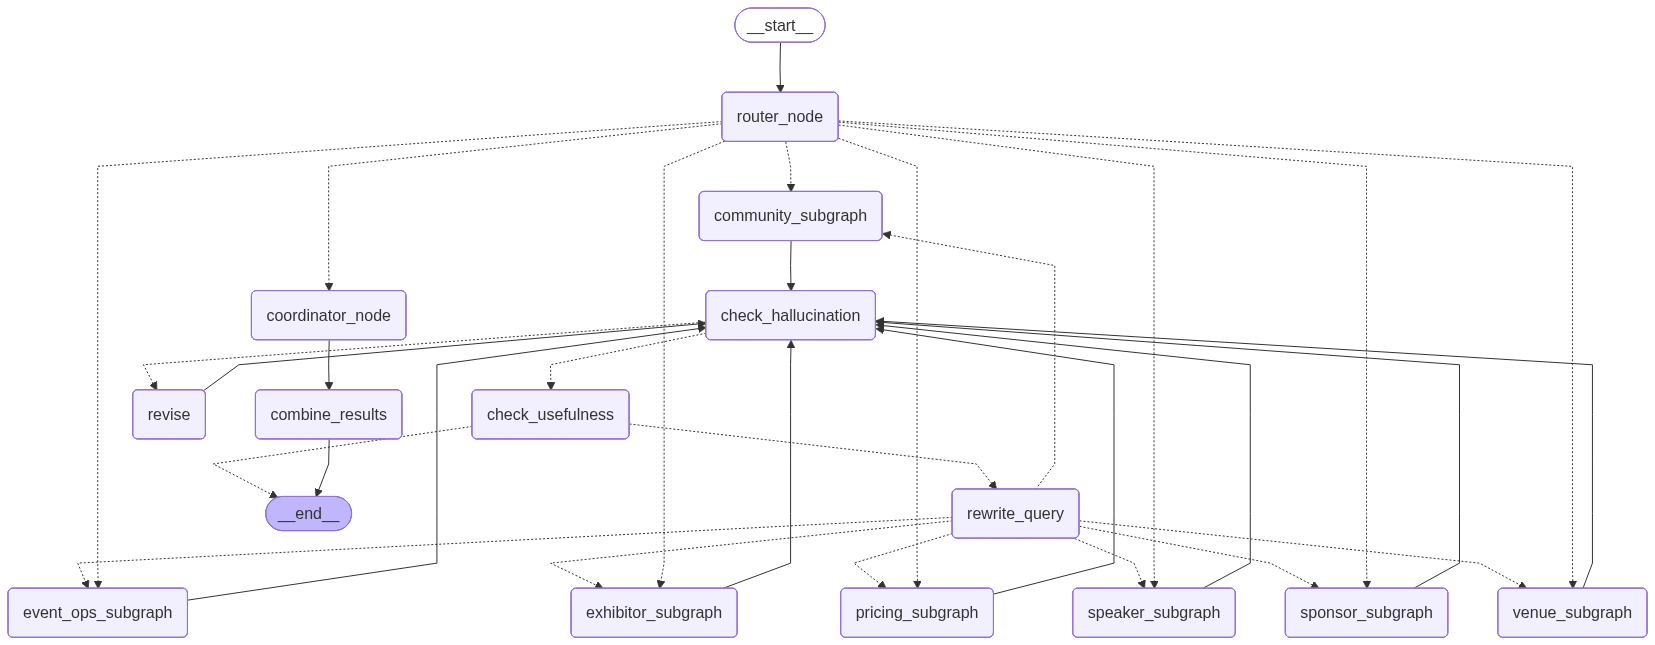

In [48]:
graph